# Ship Detection in Satellite Images with YOLO11 - v4 Runs (Recall Tuning + SAHI)

## Practical Work — AI Diploma: Computer Vision

---

Fine-tune YOLO11 to detect **ships** in **satellite images**, running entirely in a local Python environment.

### Pipeline
```
Kaggle Dataset        Roboflow             YOLO11 Training       Deploy
(Satellite images) -> (Ship annotation) -> (Fine-tuning)      -> (API)
```

## v4 — Recall Tuning + SAHI

This notebook is a focused variant of v2. It **skips** one-time steps already completed
(Kaggle exploration, Roboflow upload/annotation) and runs only what changes:

- **Training** with recall-targeted hyperparameters (`copy_paste`, `erasing`, `iou`, `scale`, `max_det`)
- **Evaluation** on the test set
- **SAHI inference** (Section 9) — sliced inference to recover small ships missed in full-scene prediction

Prerequisites (same as v2):
1. Install dependencies: `uv sync`
2. `.env` file with `ROBOFLOW_API_KEY`, `KAGGLE_USERNAME`, `KAGGLE_KEY`
3. Annotated dataset already generated in Roboflow (downloaded automatically if absent)


---
## Section 0: Environment Setup

In [1]:
!nvidia-smi

Thu Jun  4 12:49:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 573.91                 Driver Version: 573.91         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A4000 Laptop GPU  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   54C    P8             16W /  100W |    1699MiB /   8192MiB |     14%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import ultralytics
from IPython.display import Image as IPyImage, display

ROOT = Path.cwd()
DATASETS_DIR = ROOT / "datasets"
RUNS_DIR = ROOT / "runs"
MODELS_DIR = ROOT / "models"
KAGGLE_DIR = DATASETS_DIR / "ships_satellite"
KAGGLE_DATASET = "rhammell/ships-in-satellite-imagery"
MODEL_NAME = "yolo11m.pt"

DATASETS_DIR.mkdir(exist_ok=True)
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Project root : {ROOT}")
print(f"PyTorch      : {torch.__version__}")
print(f"Device       : {device}")
ultralytics.checks()

Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)
Setup complete  (12 CPUs, 63.7 GB RAM, 873.8/952.6 GB disk)


In [3]:
from dotenv import load_dotenv

load_dotenv()

ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")
KAGGLE_USERNAME = os.getenv("KAGGLE_USERNAME")
KAGGLE_KEY = os.getenv("KAGGLE_KEY")

missing = [
    k
    for k, v in {
        "ROBOFLOW_API_KEY": ROBOFLOW_API_KEY,
        "KAGGLE_USERNAME": KAGGLE_USERNAME,
        "KAGGLE_KEY": KAGGLE_KEY,
    }.items()
    if not v
]

if missing:
    raise ValueError(f"Missing keys in .env: {', '.join(missing)}")

# Write kaggle.json expected by the kaggle CLI
kaggle_config_dir = Path.home() / ".kaggle"
kaggle_config_dir.mkdir(exist_ok=True)
kaggle_json = kaggle_config_dir / "kaggle.json"
kaggle_json.write_text(f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_KEY}"}}')
kaggle_json.chmod(0o600)

print("Secrets loaded successfully.")

Secrets loaded successfully.


---
## Section 1: Dataset

The Kaggle download and Roboflow annotated dataset are reused from previous runs.
Both steps below auto-skip if the data is already present locally.


In [19]:
import kaggle

# The kaggle API unzips into a subfolder that mirrors the zip structure:
# KAGGLE_DIR / "shipsnet" / "shipsnet" / *.png
SHIPSNET_DIR = KAGGLE_DIR / "shipsnet" / "shipsnet"

if SHIPSNET_DIR.exists() and any(SHIPSNET_DIR.iterdir()):
    print("Dataset already present — skipping download.")
else:
    print("Downloading dataset from Kaggle...")
    kaggle.api.dataset_download_files(
        KAGGLE_DATASET,
        path=str(KAGGLE_DIR),
        unzip=True,
    )
    print("Download complete.")

ship_images = list(SHIPSNET_DIR.glob("1__*.png"))
nonship_images = list(SHIPSNET_DIR.glob("0__*.png"))

print(f"\nshipsnet directory : {SHIPSNET_DIR}")
print(f"  ship chips       : {len(ship_images)}")
print(f"  non-ship chips   : {len(nonship_images)}")
print(f"  total            : {len(ship_images) + len(nonship_images)}")

Dataset already present — skipping download.

shipsnet directory : c:\Users\leona\source\repos\diplo-mod-2\datasets\ships_satellite\shipsnet\shipsnet
  ship chips       : 1000
  non-ship chips   : 3000
  total            : 4000


---
## Section 3: Download Annotated Dataset from Roboflow

Once annotation and dataset generation are done in Roboflow, download it here.

In [5]:
from roboflow import Roboflow

WORKSPACE_NAME = "leonardos-workspace-yllzl"
PROJECT_NAME = "ship-4jnj0-ku1a7"
VERSION_NUMBER = 1

ROBOFLOW_DIR = DATASETS_DIR / "roboflow_annotated"

if (ROBOFLOW_DIR / "data.yaml").exists():
    print(f"Annotated dataset already present at {ROBOFLOW_DIR} — skipping download.")
else:
    print(f"Connecting to Roboflow project '{PROJECT_NAME}'...")
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)

    print(f"Downloading version {VERSION_NUMBER} in yolov11 format...")
    project.version(VERSION_NUMBER).download("yolov11", location=str(ROBOFLOW_DIR))
    print("Download complete.")

DATA_YAML = ROBOFLOW_DIR / "data.yaml"
print(f"\nDataset location : {ROBOFLOW_DIR}")
print(f"data.yaml        : {DATA_YAML}")

Annotated dataset already present at c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated — skipping download.

Dataset location : c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated
data.yaml        : c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\data.yaml


In [7]:
print("Dataset statistics:")
print("-" * 40)

for split in ["train", "valid", "test"]:
    img_dir = ROBOFLOW_DIR / split / "images"
    label_dir = ROBOFLOW_DIR / split / "labels"
    if not img_dir.exists():
        continue
    images = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    ann_count = sum(
        len([line for line in p.read_text().splitlines() if line.strip()])
        for p in label_dir.glob("*.txt")
    )
    print(f"  {split:8s}: {len(images):4d} images, {ann_count:5d} ship annotations")

print("-" * 40)

Dataset statistics:
----------------------------------------
  train   : 1535 images,  7488 ship annotations
  valid   :  512 images,  2606 ship annotations
  test    :  512 images,  2768 ship annotations
----------------------------------------


## Section 4: Fine-tuning YOLO11 — v4 (Recall Tuning)

Changes vs. v2 targeting improved recall:

| Parameter | v2 value | v4 value | Reason |
|-----------|----------|----------|--------|
| `copy_paste` | 0.1 | **0.3** | More ship instances via augmentation |
| `erasing` | 0.4 (default) | **0.0** | Prevent erasing ship pixels during training |
| `iou` | 0.7 (default) | **0.5** | Accept less-perfect box matches; helps with noisy Auto Label annotations |
| `scale` | 0.5 | **0.7** | Expose model to smaller relative object sizes |
| `max_det` | 300 (default) | **500** | Recover detections in dense port scenes |
| `epochs` | 100 | **100** | Kept — sufficient for convergence |
| `cls` | 1.5 | **1.5** | Kept — strong classification signal |
| `mosaic` | 1.0 | **1.0** | Kept — critical for small object detection |
| `mixup` | 0.1 | **0.1** | Kept — adds variability |
| `degrees` | 30 | **30** | Kept — satellites capture ships at any angle |
| `flipud` | 0.5 | **0.5** | Kept — no absolute up in satellite images |


In [6]:
from ultralytics import YOLO
from ultralytics.utils.downloads import safe_download

FORCE_RETRAIN = True  # set to True to start a new experiment ignoring existing runs

existing_runs = sorted(
    (RUNS_DIR / "detect").glob("ship_detection_v1*/weights/best.pt"),
    key=lambda p: p.stat().st_mtime,
)

if existing_runs and not FORCE_RETRAIN:
    BEST_WEIGHTS = existing_runs[-1]
    TRAIN_DIR = BEST_WEIGHTS.parent.parent
    print("Existing training run found — skipping training.")
    print(f"  Run      : {TRAIN_DIR}")
    print(f"  Weights  : {BEST_WEIGHTS}")
    print("\nSet FORCE_RETRAIN = True to start a new experiment.")
else:
    MODEL_PATH = MODELS_DIR / MODEL_NAME
    if not MODEL_PATH.exists():
        print(f"Downloading {MODEL_NAME} to {MODELS_DIR}...")
        safe_download(
            url=f"https://github.com/ultralytics/assets/releases/latest/download/{MODEL_NAME}",
            file=MODEL_PATH,
        )
        print(f"Saved to {MODEL_PATH}")
    else:
        print(f"Model already present at {MODEL_PATH}")

    model = YOLO(str(MODEL_PATH))
    results = model.train(
        data=str(DATA_YAML),
        epochs=100,
        imgsz=640,
        batch=-1,
        patience=30,
        device=device,
        cos_lr=True,
        lrf=0.01,
        weight_decay=0.0005,
        warmup_epochs=3,
        cls=1.5,
        degrees=30.0,
        flipud=0.5,
        fliplr=0.5,
        scale=0.7,
        shear=2.0,
        mosaic=1.0,
        mixup=0.1,
        copy_paste=0.3,
        erasing=0.0,
        max_det=500,
        plots=True,
        name="ship_detection_v4",
        project=str(RUNS_DIR / "detect"),
    )

    TRAIN_DIR = Path(results.save_dir)
    BEST_WEIGHTS = TRAIN_DIR / "weights" / "best.pt"
    print(f"\nTraining complete. Results saved to: {TRAIN_DIR}")

Model already present at c:\Users\leona\source\repos\diplo-mod-2\models\yolo11m.pt
New https://pypi.org/project/ultralytics/8.4.60 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)
engine\trainer: task=detect, mode=train, model=c:\Users\leona\source\repos\diplo-mod-2\models\yolo11m.pt, data=c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\data.yaml, epochs=100, time=None, patience=30, batch=-1, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=c:\Users\leona\source\repos\diplo-mod-2\runs\detect, name=ship_detection_v4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, sa

100%|██████████| 5.35M/5.35M [00:00<00:00, 12.3MB/s]


AMP: checks passed 
AutoBatch: Computing optimal batch size for imgsz=640 at 60.0% CUDA memory utilization.
AutoBatch: CUDA:0 (NVIDIA RTX A4000 Laptop GPU) 8.00G total, 0.21G reserved, 0.19G allocated, 7.59G free
      Params      GFLOPs  GPU_mem (GB)  forward (ms) backward (ms)                   input                  output
    20053779       68.19         0.759         71.26         333.3        (1, 3, 640, 640)                    list
    20053779       136.4         1.288         63.58         130.3        (2, 3, 640, 640)                    list
    20053779       272.8         2.309         64.38         97.39        (4, 3, 640, 640)                    list
    20053779       545.5         4.349         94.92         126.6        (8, 3, 640, 640)                    list
    20053779        1091         8.246          2160          2631       (16, 3, 640, 640)                    list
AutoBatch: Using batch-size 8 for CUDA:0 4.69G/8.00G (59%) 


train: Scanning C:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\train\labels.cache... 1535 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1535/1535 [00:00<?, ?it/s]

WARNING  Box and segment counts should be equal, but got len(segments) = 14, len(boxes) = 7488. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


...

    100/100      4.62G      1.605      3.271      1.441         27        640: 100%|██████████| 192/192 [00:46<00:00,  4.10it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:06<00:00,  4.67it/s]

                   all        512       2606       0.77      0.468      0.522       0.26



100 epochs completed in 1.511 hours.
Optimizer stripped from c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v4\weights\last.pt, 40.5MB
Optimizer stripped from c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v4\weights\best.pt, 40.5MB

Validating c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v4\weights\best.pt...
Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)
YOLO11m summary (fused): 303 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:07<00:00,  4.47it/s]


                   all        512       2606      0.759      0.468      0.522       0.27
Speed: 0.4ms preprocess, 7.4ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v4

Training complete. Results saved to: c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v4


---
## Section 5: Training Results

Training run: c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v4

confusion_matrix_normalized.png


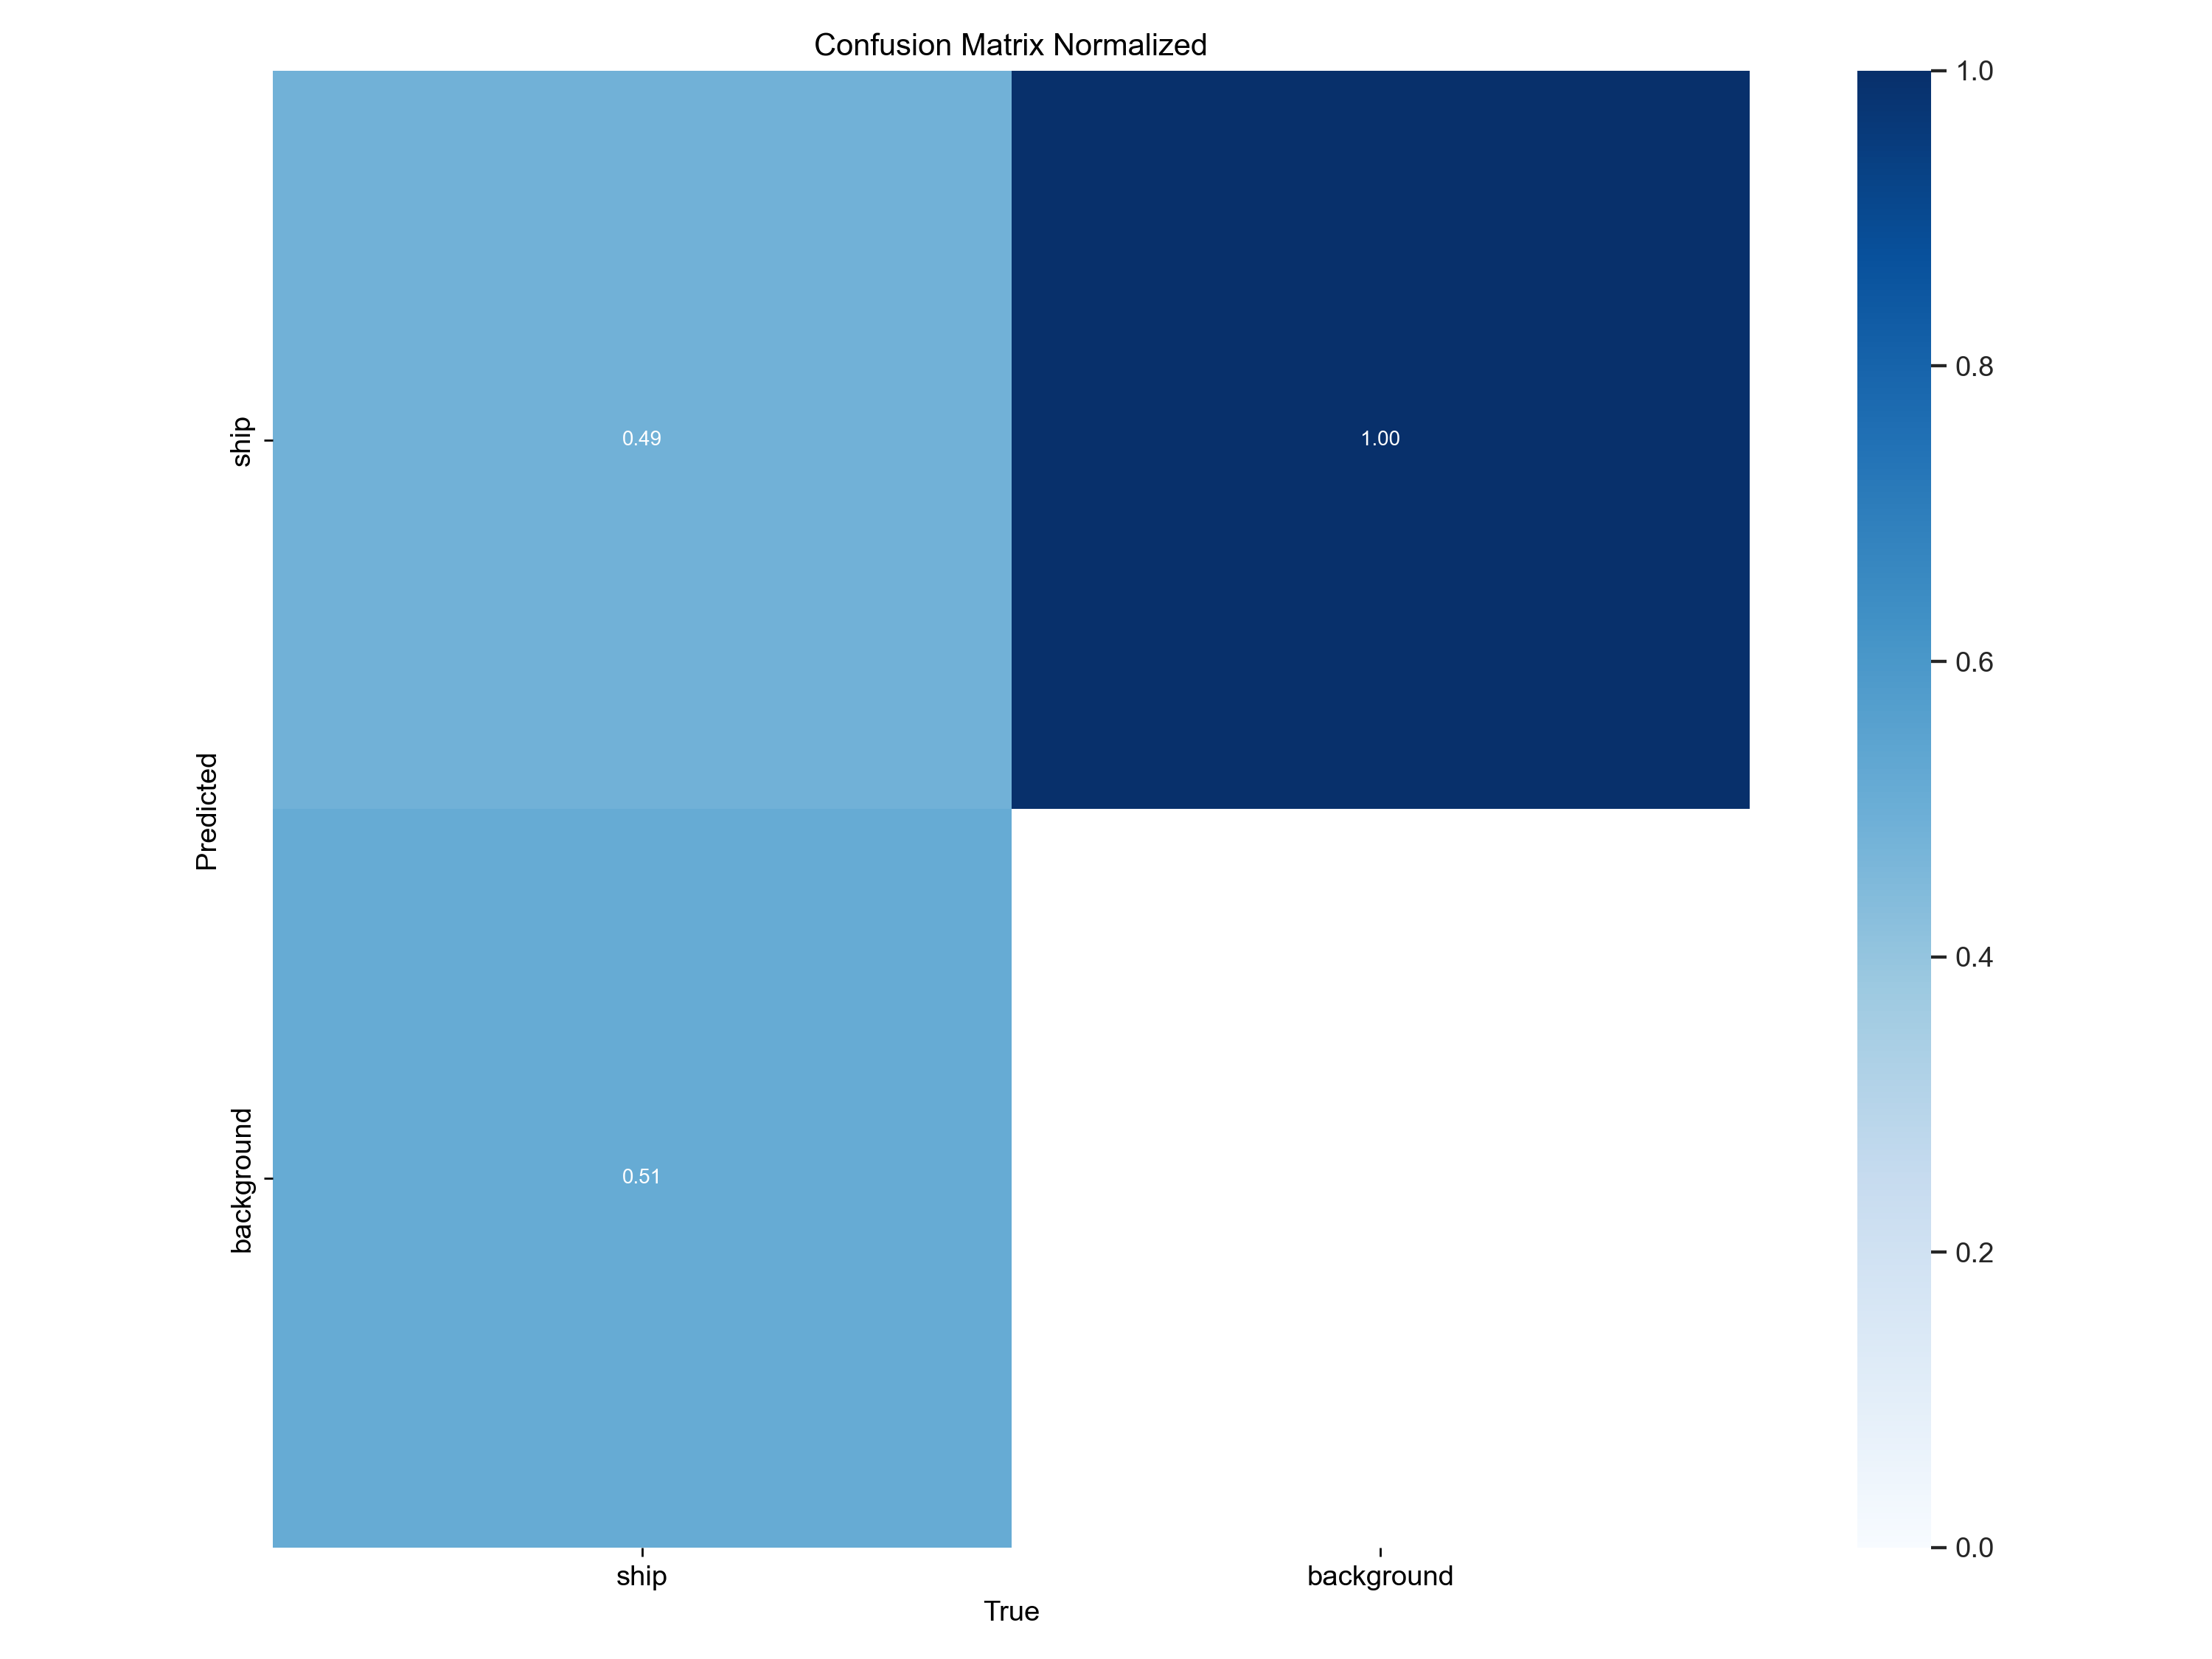


results.png


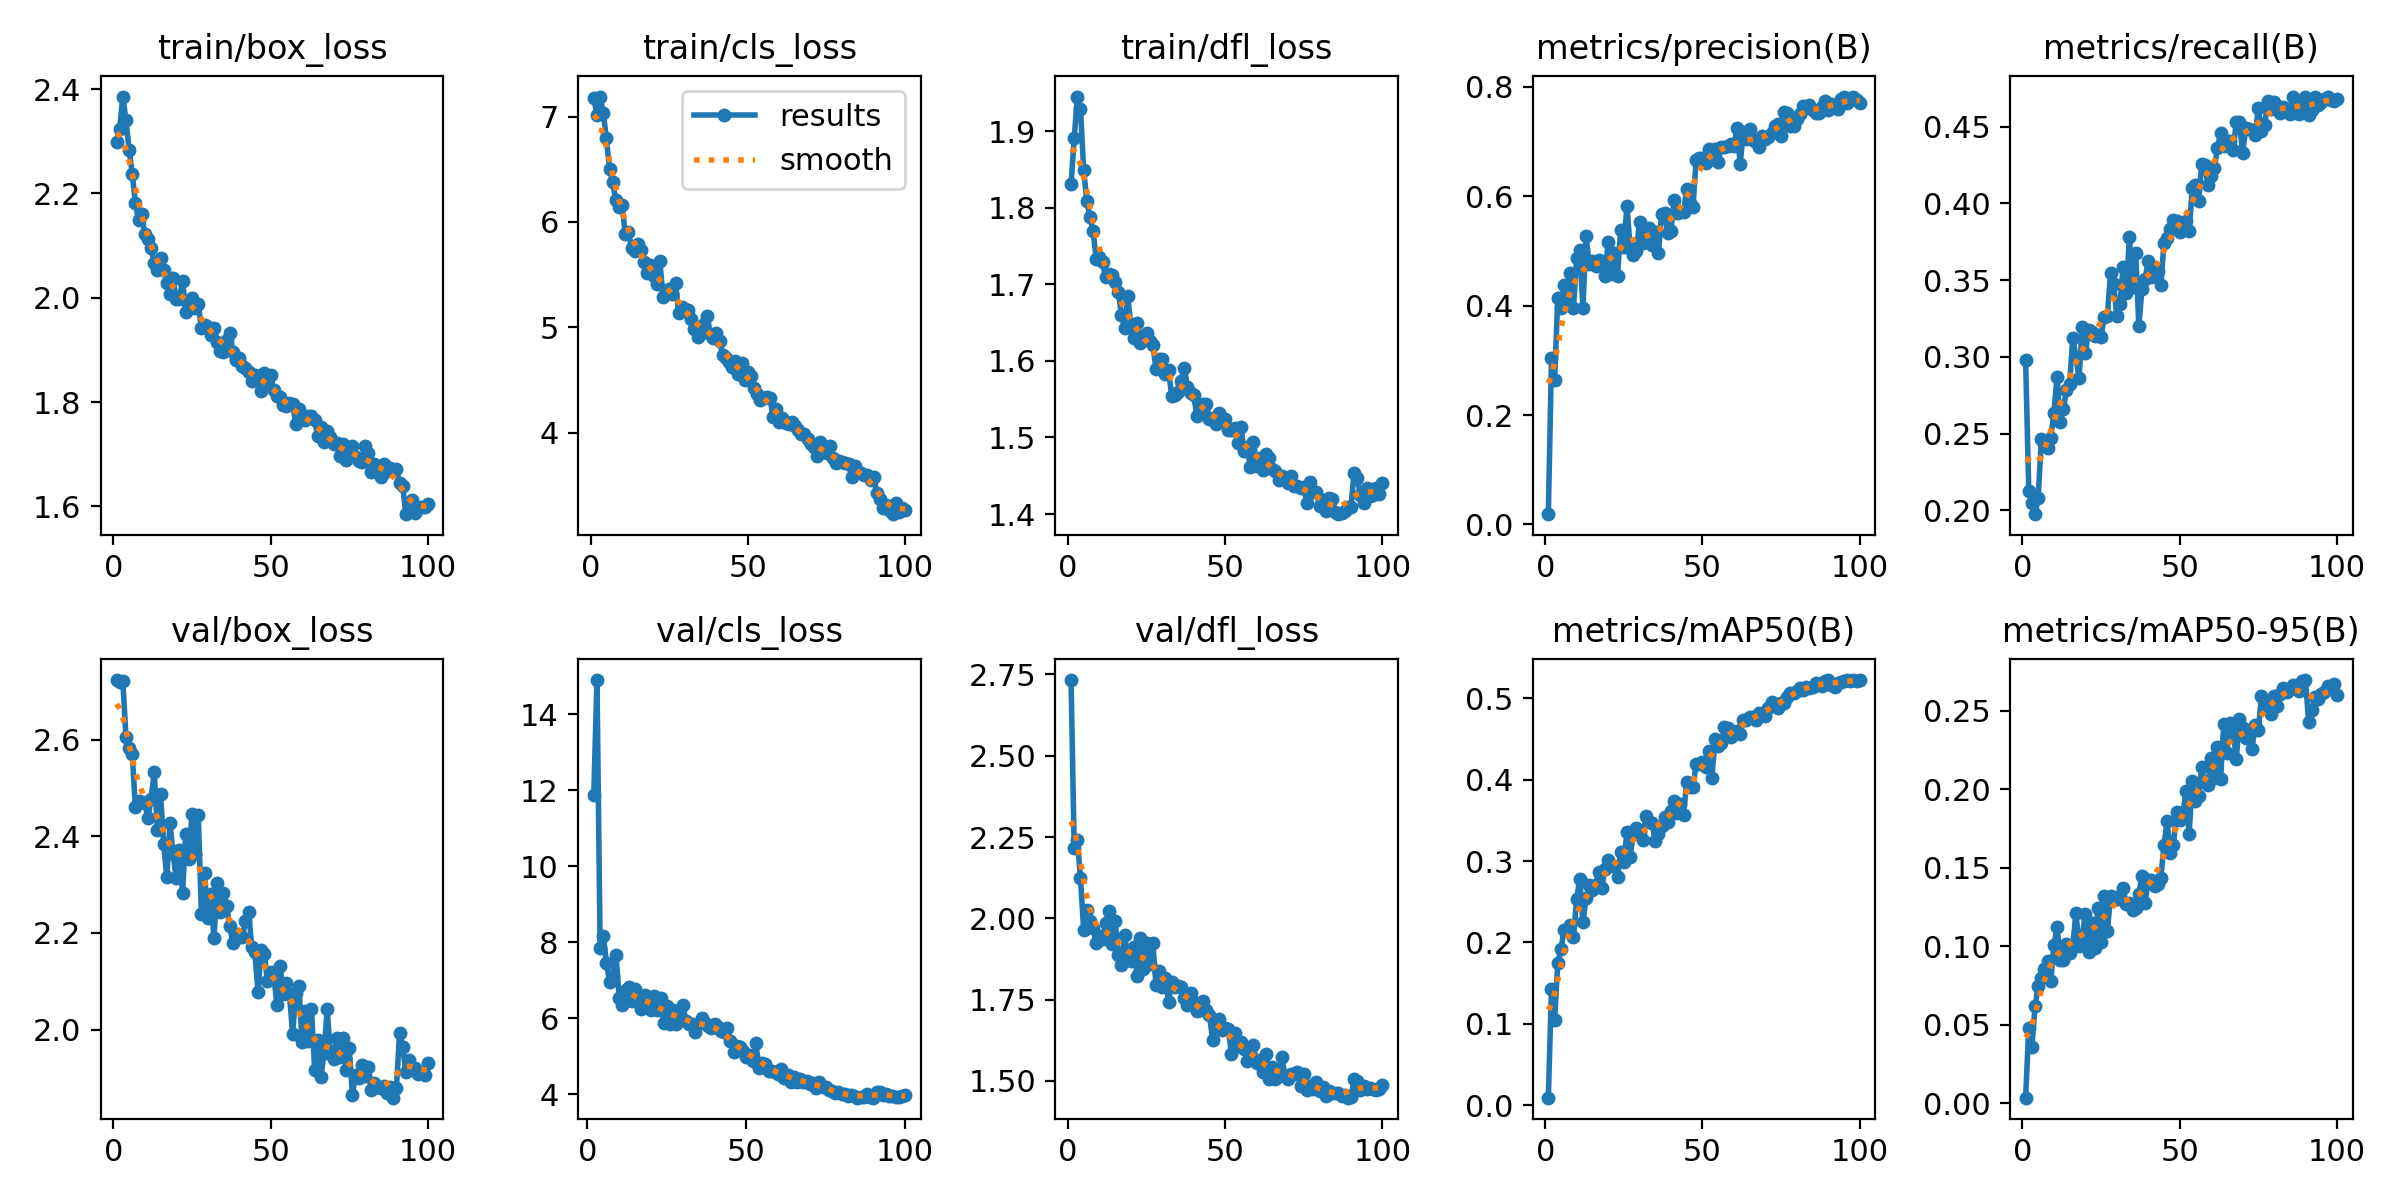


val_batch0_pred.jpg


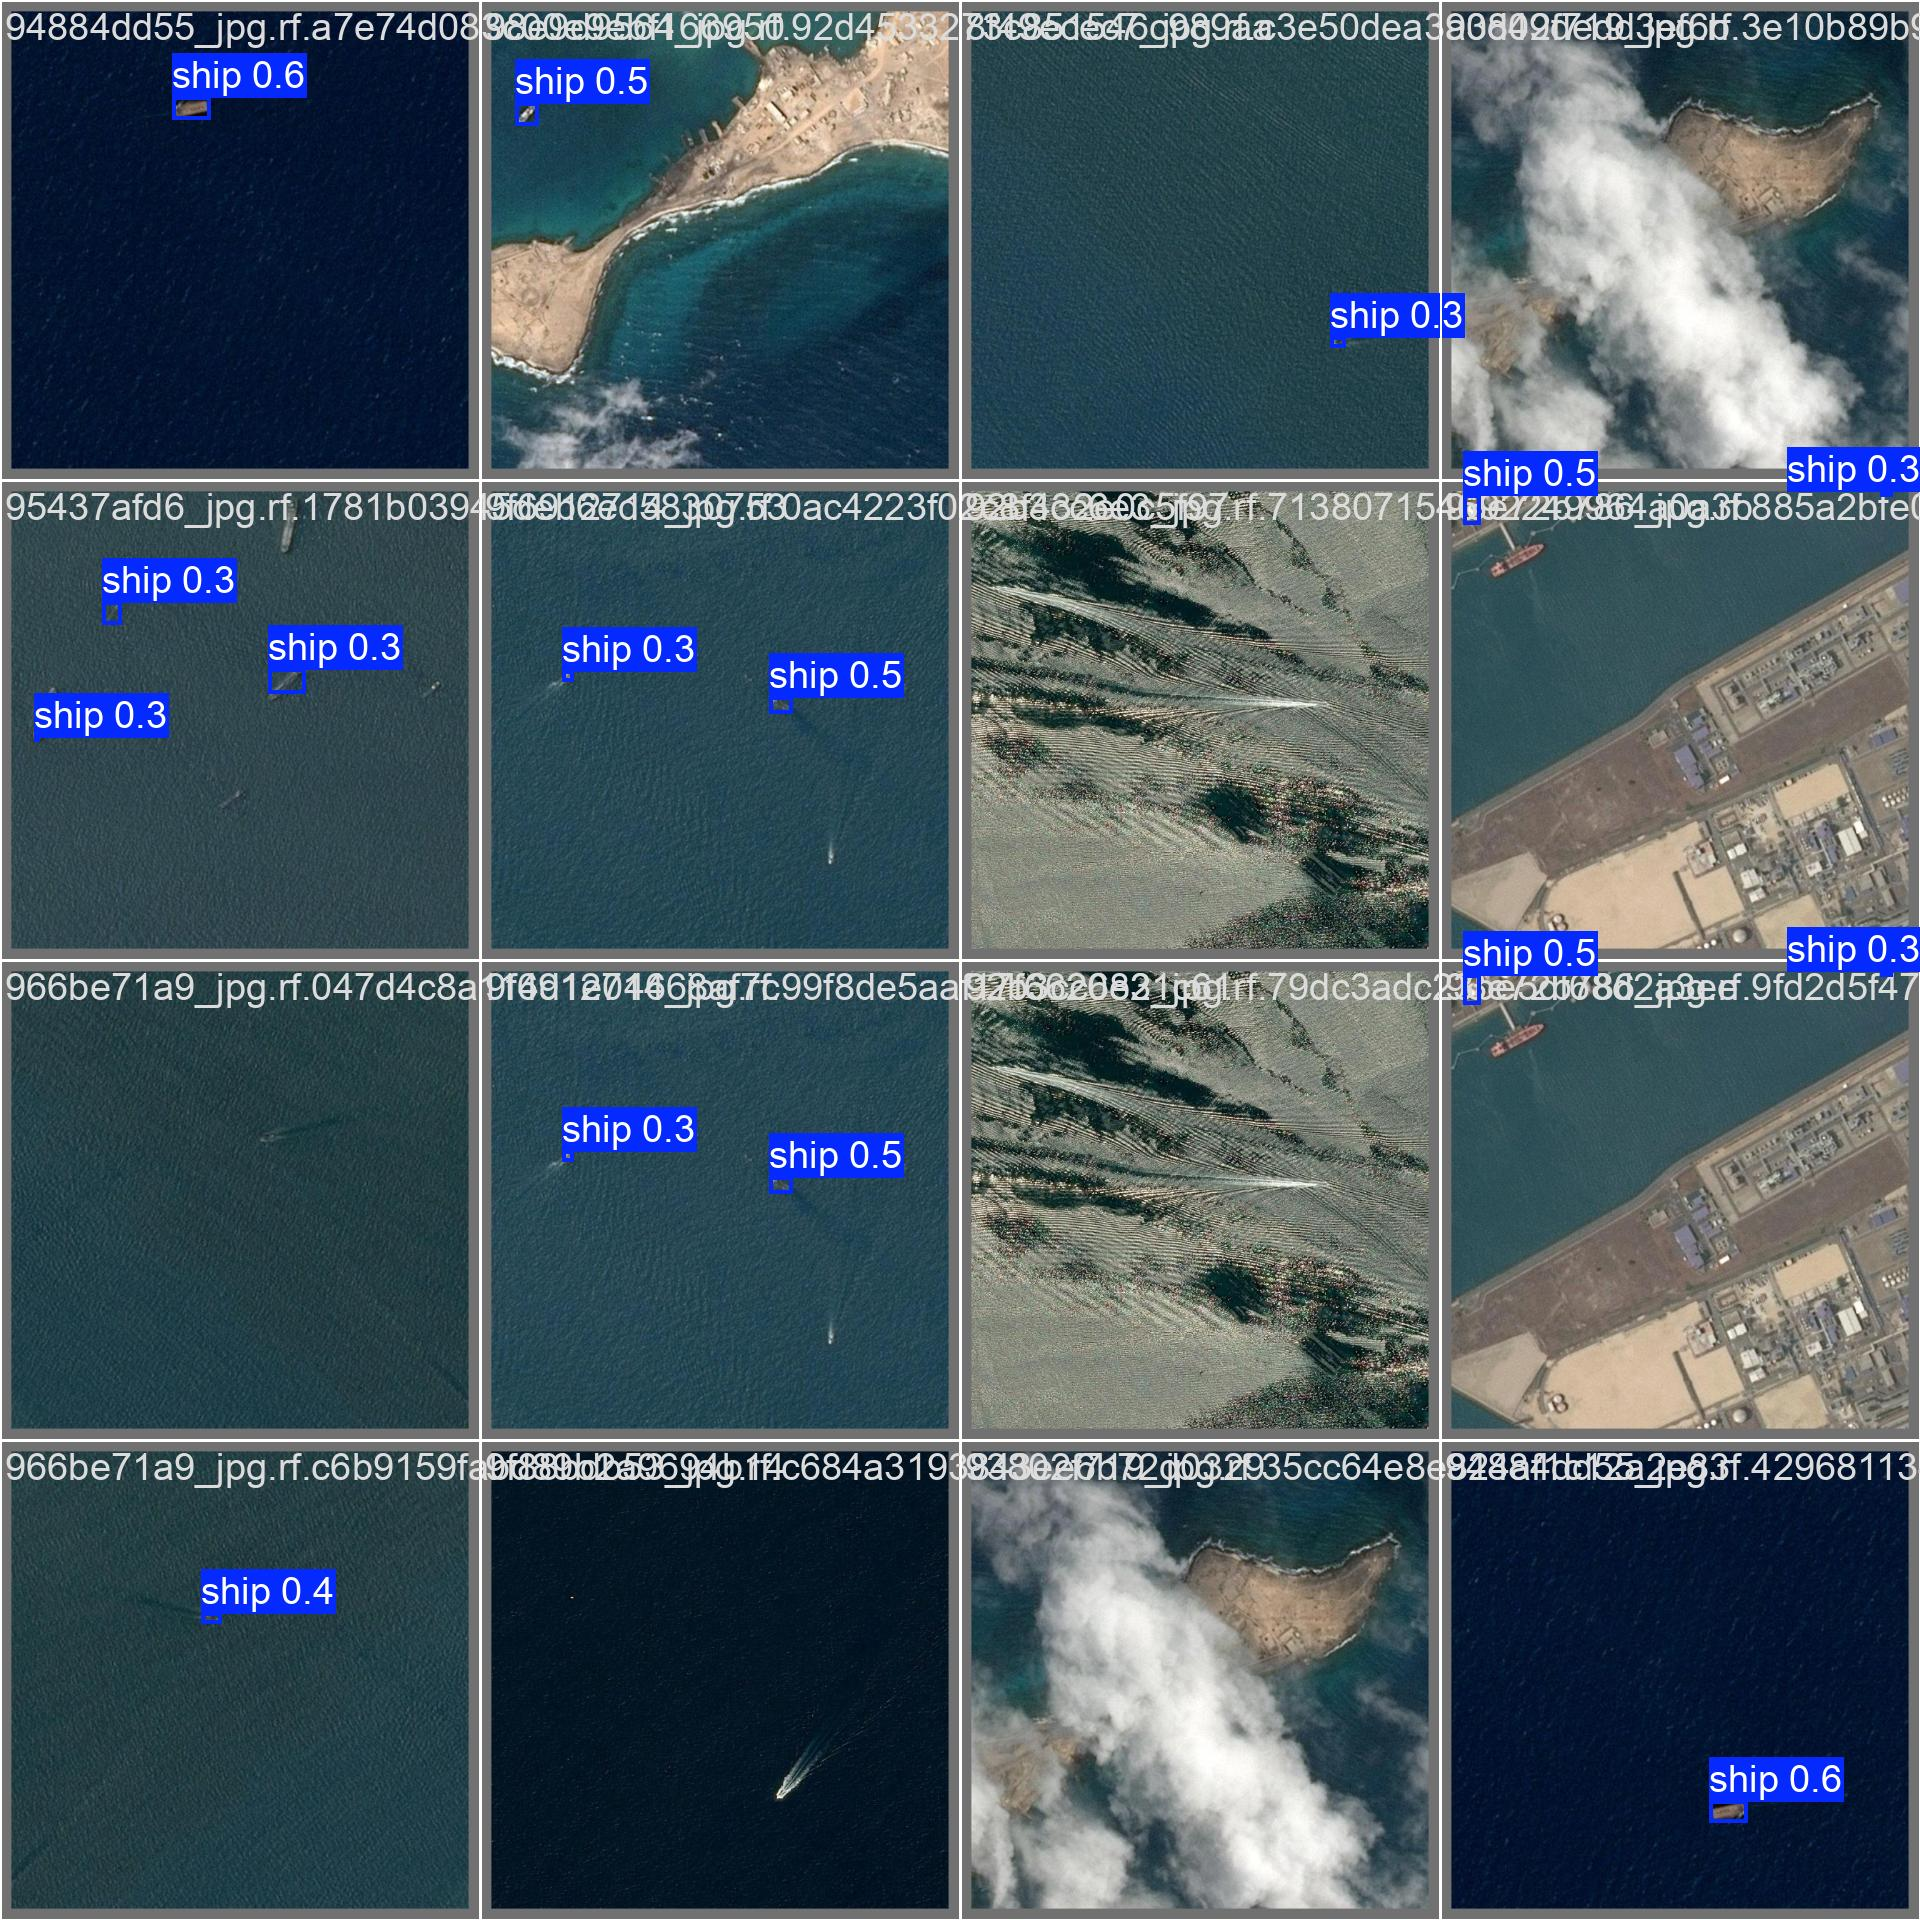

In [7]:
# Resolve latest training run if TRAIN_DIR is not set (re-running this cell after restart)
if "TRAIN_DIR" not in dir() or not Path(TRAIN_DIR).exists():
    train_dirs = sorted(
        RUNS_DIR.glob("detect/ship_detection_v4*/"), key=lambda p: p.stat().st_mtime
    )
    TRAIN_DIR = train_dirs[-1]
    BEST_WEIGHTS = TRAIN_DIR / "weights" / "best.pt"

print(f"Training run: {TRAIN_DIR}")

for filename in ["confusion_matrix_normalized.png", "results.png", "val_batch0_pred.jpg"]:
    path = TRAIN_DIR / filename
    if path.exists():
        print(f"\n{filename}")
        display(IPyImage(filename=str(path), width=800))

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = TRAIN_DIR / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

best_epoch = df["metrics/mAP50(B)"].idxmax()
best = df.iloc[best_epoch]

print("Training metrics summary:")
print(f"  Best epoch       : {best_epoch + 1}")
print(f"  mAP@50           : {best.get('metrics/mAP50(B)', 0):.4f}")
print(f"  mAP@50-95        : {best.get('metrics/mAP50-95(B)', 0):.4f}")
print(f"  Precision        : {best.get('metrics/precision(B)', 0):.4f}")
print(f"  Recall           : {best.get('metrics/recall(B)', 0):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df.index + 1, df["metrics/mAP50(B)"], label="mAP@50")
ax1.plot(df.index + 1, df["metrics/mAP50-95(B)"], label="mAP@50-95")
ax1.axvline(
    best_epoch + 1, color="red", linestyle="--", alpha=0.5, label=f"best (epoch {best_epoch + 1})"
)
ax1.set(title="Detection Metrics per Epoch", xlabel="Epoch", ylabel="mAP")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(df.index + 1, df["train/box_loss"], label="train")
ax2.plot(df.index + 1, df["val/box_loss"], label="val")
ax2.set(title="Box Loss: Train vs Validation", xlabel="Epoch", ylabel="Loss")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Training metrics summary:
  Best epoch       : 96
  mAP@50           : 0.5225
  mAP@50-95        : 0.2618
  Precision        : 0.7711
  Recall           : 0.4678


<Figure size 1400x500 with 2 Axes>

---
## Section 6: Validation

Evaluate the model on the **test set** — data the model never saw during training.

Target metrics for a usable ship detector:
- **mAP@50 > 0.70** — good overall detection quality
- **Recall > Precision** — for maritime monitoring, missing a ship (false negative) is worse than a false alarm

In [9]:
from ultralytics import YOLO

val_model = YOLO(str(BEST_WEIGHTS))
val_results = val_model.val(
    data=str(DATA_YAML),
    split="test",
    conf=0.10,  # lower threshold prioritises recall over precision
    iou=0.5,
)

print(f"\nmAP@50    : {val_results.box.map50:.4f}")
print(f"mAP@50-95 : {val_results.box.map:.4f}")
print(f"Precision : {val_results.box.mp:.4f}")
print(f"Recall    : {val_results.box.mr:.4f}")

Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)
YOLO11m summary (fused): 303 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs


val: Scanning C:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\labels.cache... 512 images, 0 backgrounds, 0 corrupt: 100%|██████████| 512/512 [00:00<?, ?it/s]

WARNING  Box and segment counts should be equal, but got len(segments) = 7, len(boxes) = 2768. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:09<00:00,  3.40it/s]


                   all        512       2768      0.803       0.48      0.634      0.355
Speed: 0.4ms preprocess, 12.8ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to C:\Users\leona\source\repos\diplo-mod-2\runs\detect\val6

mAP@50    : 0.6343
mAP@50-95 : 0.3546
Precision : 0.8034
Recall    : 0.4798


---
## Section 7: Inference with the Fine-tuned Model

In [10]:
from ultralytics import YOLO

test_images_dir = ROBOFLOW_DIR / "test" / "images"
inf_model = YOLO(str(BEST_WEIGHTS))

inf_results = inf_model.predict(
    source=str(test_images_dir),
    conf=0.25,
    iou=0.45,
    save=True,
    name="ship_detection_test",
    project=str(RUNS_DIR / "detect"),
)

predict_dirs = sorted(
    RUNS_DIR.glob("detect/ship_detection_test*/"), key=lambda p: p.stat().st_mtime
)
latest_predict = predict_dirs[-1]
print(f"Predictions saved to: {latest_predict}")


image 1/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\0150b2c24_jpg.rf.7f45d612069a712643ea16a20a5ed840.jpg: 640x640 (no detections), 27.6ms
image 2/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\042c8028f_jpg.rf.09bb8db398c9799c6ad73c43d0cf5ce0.jpg: 640x640 2 ships, 24.2ms
image 3/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\042c8028f_jpg.rf.99bd39aed3fef732f1be4c1c17da5270.jpg: 640x640 2 ships, 17.0ms
image 4/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\042c8028f_jpg.rf.b25229bd9f4e0ee92fa515edd146529a.jpg: 640x640 1 ship, 20.6ms
image 5/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\04e7626b1_jpg.rf.bc7c76ff2519bc79fd2a3122b62100b1.jpg: 640x640 (no detections), 21.3ms
image 6/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\056949650_jpg.rf.8bf859c61ffed88571ec

Showing 6 sample predictions:


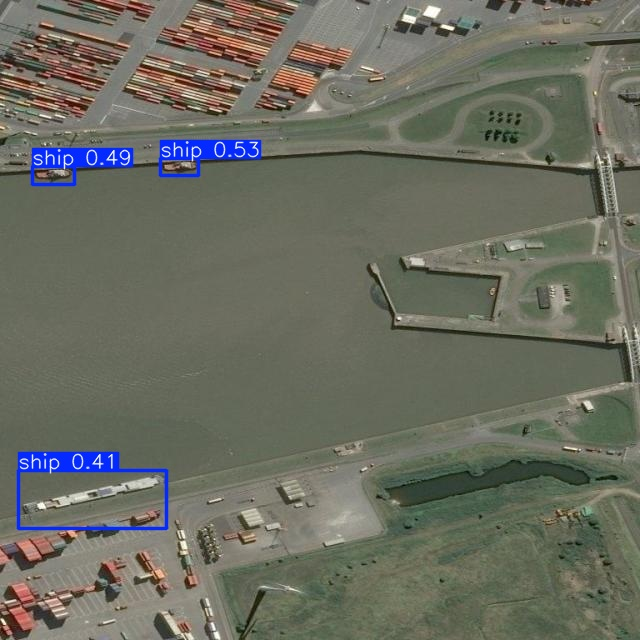

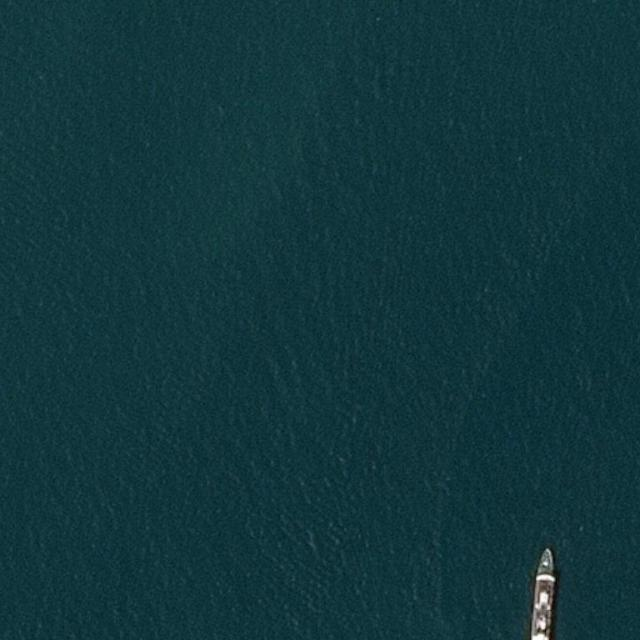

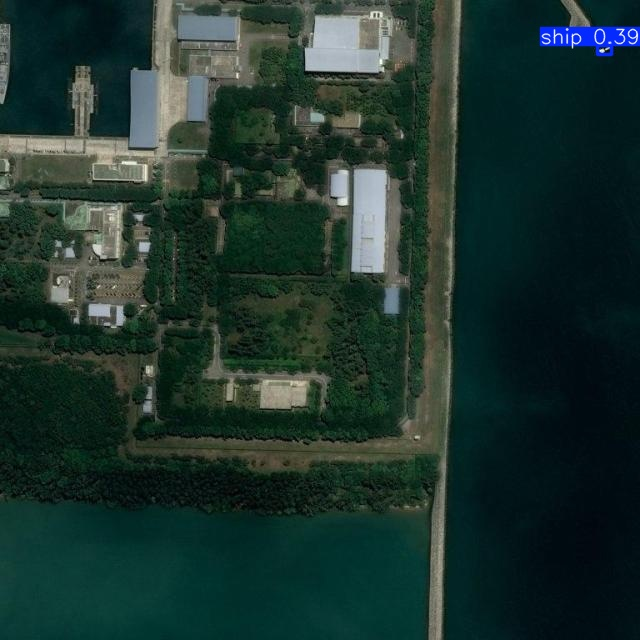

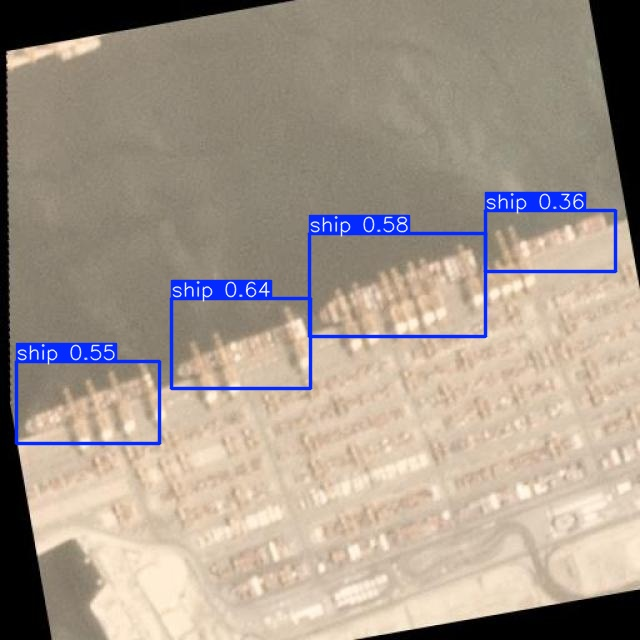

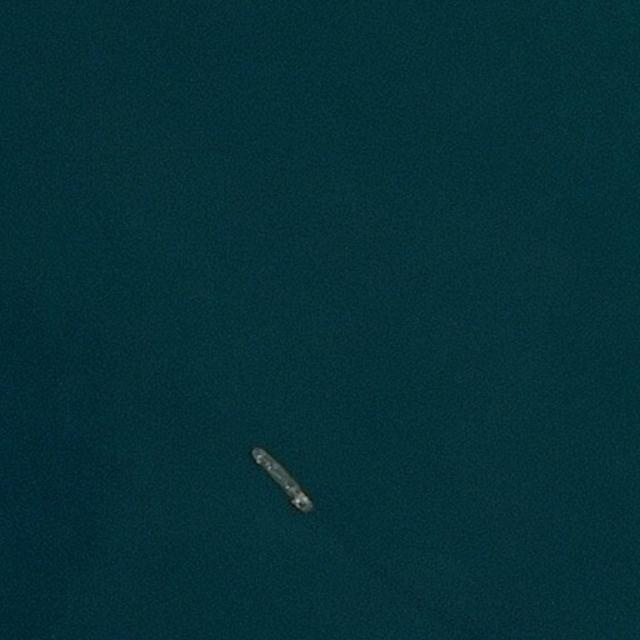

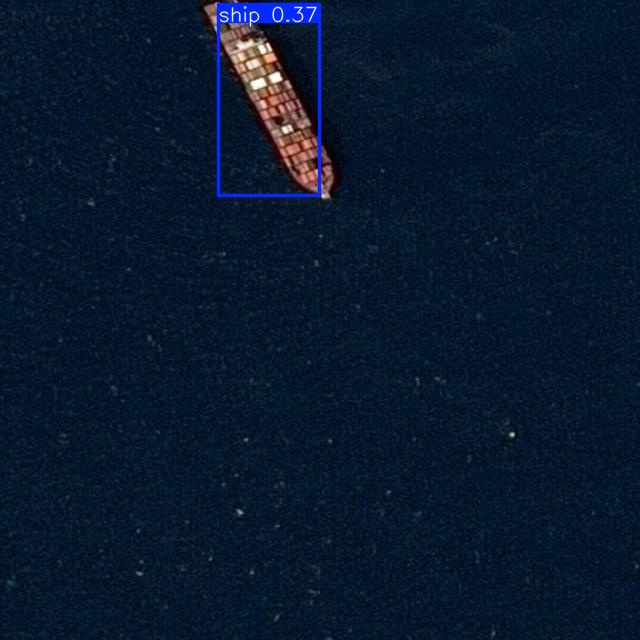

In [11]:
result_images = list(latest_predict.glob("*.jpg")) + list(latest_predict.glob("*.png"))
sample = random.sample(result_images, min(6, len(result_images)))

print(f"Showing {len(sample)} sample predictions:")
for img_path in sample:
    display(IPyImage(filename=str(img_path), width=700))
    print()


0: 640x640 2 ships, 74.9ms
Speed: 4.9ms preprocess, 74.9ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)
Image : 042c8028f_jpg.rf.09bb8db398c9799c6ad73c43d0cf5ce0.jpg
Ships detected: 2
  Ship 1: bbox=(183,146,224,167)  size=41x21px  conf=0.44
  Ship 2: bbox=(504,134,513,141)  size=9x8px  conf=0.26


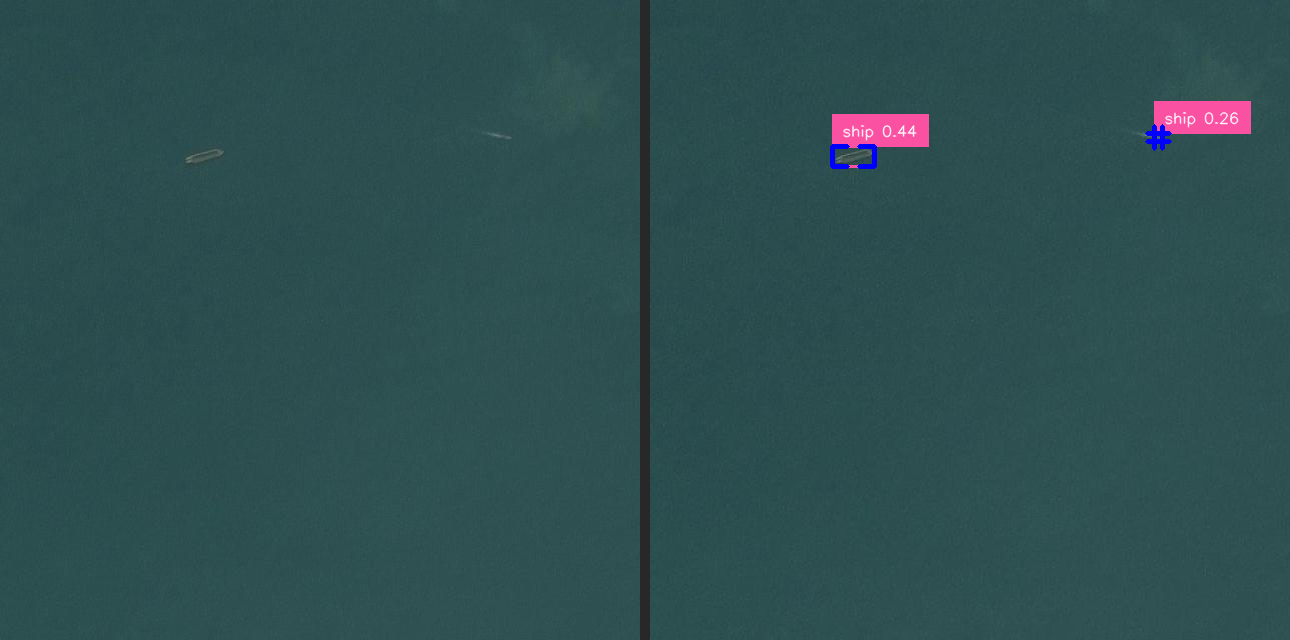

Left: original | Right: 2 ship(s) detected (conf≥0.25)


In [39]:
from PIL import Image, ImageDraw
import supervision as sv
import numpy as np
from IPython.display import display as ipy_display
import io, matplotlib.pyplot as plt

test_images = list(test_images_dir.glob("*.jpg")) + list(test_images_dir.glob("*.png"))
img_path = random.choice(test_images)
image = Image.open(img_path).convert("RGB")

result = inf_model.predict(image, conf=0.25, iou=0.45)[0]
detections = sv.Detections.from_ultralytics(result)

print(f"Image : {img_path.name}")
print(f"Ships detected: {len(detections)}")

if len(detections) == 0:
    print("  No ships detected at conf=0.25")
else:
    for i, (box, conf) in enumerate(zip(detections.xyxy, detections.confidence), start=1):
        x1, y1, x2, y2 = box
        print(
            f"  Ship {i}: bbox=({x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f})  "
            f"size={x2 - x1:.0f}x{y2 - y1:.0f}px  conf={conf:.2f}"
        )

# Annotate — supervision requires numpy arrays
frame = np.array(image)
labels = (
    [f"ship {c:.2f}" for c in detections.confidence]
    if detections.confidence is not None else []
)
annotated = sv.BoxAnnotator(thickness=2).annotate(scene=frame.copy(), detections=detections)
annotated = sv.LabelAnnotator(text_color=sv.Color.WHITE, text_scale=0.5).annotate(
    scene=annotated, detections=detections, labels=labels
)
annotated = sv.BoxCornerAnnotator(color=sv.Color.RED).annotate(
    scene=annotated, detections=detections
)

# Build side-by-side composite with PIL and display via IPython
orig_pil = image
ann_pil  = Image.fromarray(annotated)
w, h = orig_pil.size
composite = Image.new("RGB", (w * 2 + 10, h), color=(40, 40, 40))
composite.paste(orig_pil, (0, 0))
composite.paste(ann_pil,  (w + 10, 0))

buf = io.BytesIO()
composite.save(buf, format="PNG")
buf.seek(0)
from IPython.display import Image as IPyImg
ipy_display(IPyImg(data=buf.read(), width=900))
print(f"Left: original | Right: {len(detections)} ship(s) detected (conf≥0.25)")

---
## Section 8: Confidence Threshold Analysis

- **Low conf (0.10–0.20):** more detections, more false positives
- **High conf (0.50–0.70):** higher precision, may miss small ships

For maritime surveillance, **recall is prioritised** — missing a ship is worse than a false alarm.
Recommended range: **0.25–0.40**.

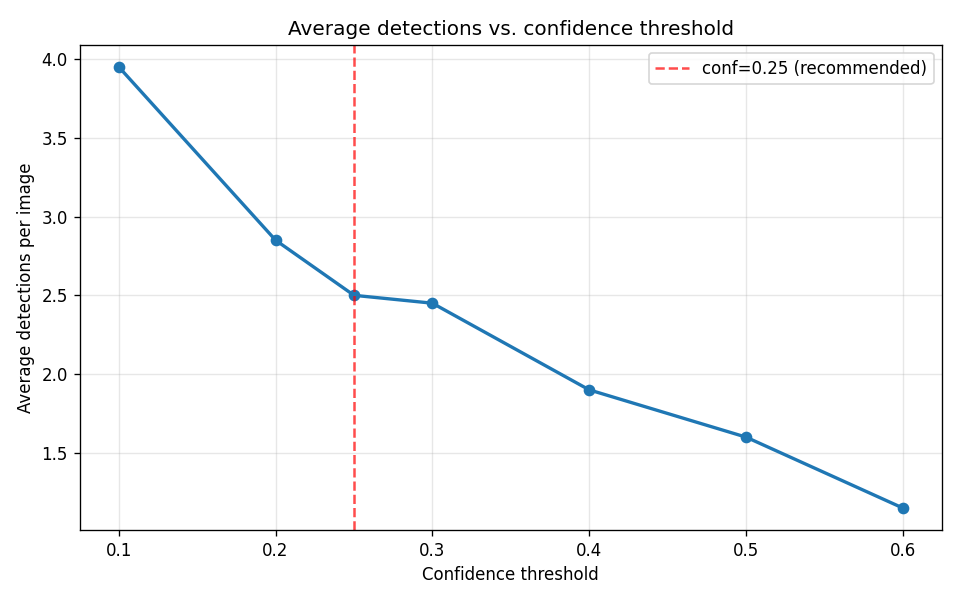

In [41]:
import io
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImg, display as ipy_display

sweep_sample = random.sample(test_images, min(20, len(test_images)))
conf_values = [0.10, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60]
avg_detections = []

for conf in conf_values:
    total = sum(
        len(inf_model.predict(str(p), conf=conf, verbose=False)[0].boxes) for p in sweep_sample
    )
    avg_detections.append(total / len(sweep_sample))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(conf_values, avg_detections, marker="o", linewidth=2)
ax.axvline(0.25, color="red", linestyle="--", alpha=0.7, label="conf=0.25 (recommended)")
ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Average detections per image")
ax.set_title("Average detections vs. confidence threshold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=120)
buf.seek(0)
plt.close(fig)
ipy_display(IPyImg(data=buf.read()))

---
## Section 9: SAHI — Sliced Inference for Full Satellite Scenes

SAHI (*Slicing Aided Hyper Inference*) splits a high-resolution image into overlapping
tiles, runs the model on each tile, and merges detections with NMS. This recovers ships
that the model misses in full-scene inference because they are too small relative to the
entire image.

**References:**
- https://docs.ultralytics.com/guides/sahi-tiled-inference/
- https://github.com/obss/sahi

In [43]:
# Install SAHI if not present
try:
    import sahi
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "sahi", "-q"])
print("SAHI ready")

SAHI ready


Performing prediction on 9 slices.
Image      : 29a93beeb_jpg.rf.7bd7fbf33bd922eb3e16ebbd7edea476.jpg
Detections : 2
  Ship 01: bbox=(220,577,265,630)  score=0.37
  Ship 02: bbox=(275,486,320,588)  score=0.33


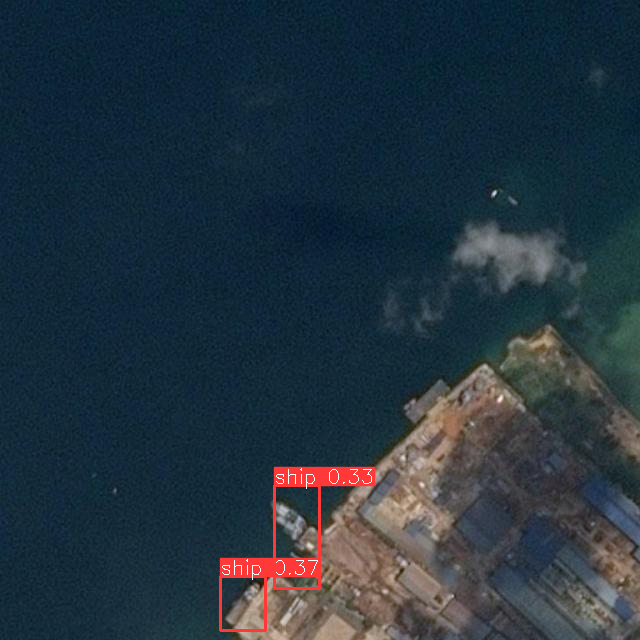

In [73]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from IPython.display import Image as IPyImage, display
import random

# Load trained model via SAHI wrapper
sahi_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=str(BEST_WEIGHTS),
    confidence_threshold=0.20,   # lower threshold to maximise recall
    device=device,
)

# Run sliced inference on a random test image
test_images = list(test_images_dir.glob("*.jpg")) + list(test_images_dir.glob("*.png"))
sample_img = random.choice(test_images)

result = get_sliced_prediction(
    str(sample_img),
    sahi_model,
    slice_height=320,        # tile size matching training chip scale
    slice_width=320,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
)

n_sahi = len(result.object_prediction_list)
print(f"Image      : {sample_img.name}")
print(f"Detections : {n_sahi}")
for i, pred in enumerate(result.object_prediction_list, 1):
    b = pred.bbox
    print(f"  Ship {i:02d}: bbox=({b.minx:.0f},{b.miny:.0f},{b.maxx:.0f},{b.maxy:.0f})  "
          f"score={pred.score.value:.2f}")

# Export annotated image
out_dir = RUNS_DIR / "detect" / "sahi_results"
out_dir.mkdir(parents=True, exist_ok=True)
result.export_visuals(export_dir=str(out_dir), file_name=sample_img.stem)
out_img = out_dir / f"{sample_img.stem}.png"
if out_img.exists():
    display(IPyImage(filename=str(out_img), width=800))

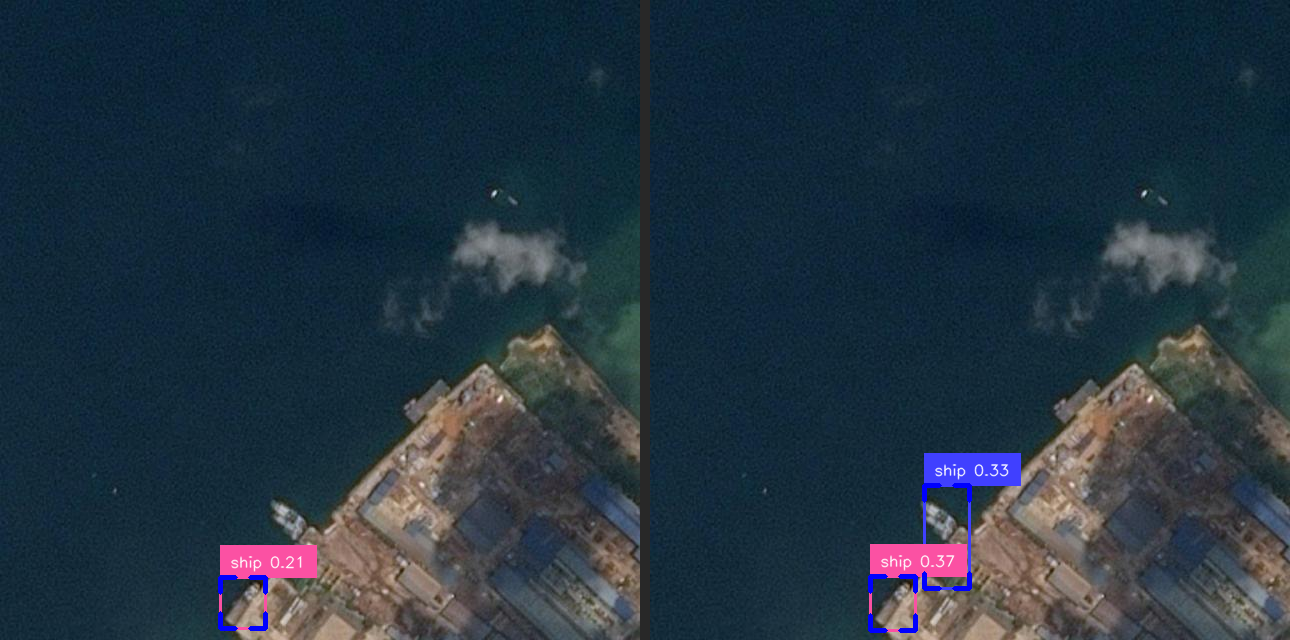

  Left  — Direct inference  :   1 detections  (conf>=0.20)
  Right — SAHI (320px tiles):   2 detections  (conf>=0.20)
  Delta : +1 ships recovered by SAHI


In [74]:
# Compare: direct inference vs SAHI — show both images side by side
from ultralytics import YOLO
from PIL import Image as PilImage
import supervision as sv
import numpy as np, io
from IPython.display import Image as IPyImg, display as ipy_display

CL = sv.ColorLookup.INDEX  # avoids class_id requirement

# --- Direct inference ---
direct_model = YOLO(str(BEST_WEIGHTS))
direct_result = direct_model.predict(str(sample_img), conf=0.20, iou=0.45, verbose=False)[0]
n_direct = len(direct_result.boxes)

orig  = PilImage.open(sample_img).convert("RGB")
frame = np.array(orig)
det_direct = sv.Detections.from_ultralytics(direct_result)
labels_direct = [f"ship {c:.2f}" for c in det_direct.confidence] if det_direct.confidence is not None else []
ann_direct = sv.BoxAnnotator(thickness=2).annotate(scene=frame.copy(), detections=det_direct, custom_color_lookup=CL)
ann_direct = sv.LabelAnnotator(text_color=sv.Color.WHITE, text_scale=0.5).annotate(
    scene=ann_direct, detections=det_direct, labels=labels_direct, custom_color_lookup=CL
)
ann_direct = sv.BoxCornerAnnotator(color=sv.Color.RED).annotate(scene=ann_direct, detections=det_direct, custom_color_lookup=CL)

# --- SAHI detections (from previous cell) ---
if result.object_prediction_list:
    boxes  = np.array([[p.bbox.minx, p.bbox.miny, p.bbox.maxx, p.bbox.maxy]
                       for p in result.object_prediction_list])
    scores = np.array([p.score.value for p in result.object_prediction_list])
    det_sahi = sv.Detections(xyxy=boxes, confidence=scores)
else:
    det_sahi = sv.Detections.empty()

labels_sahi = [f"ship {c:.2f}" for c in det_sahi.confidence] if det_sahi.confidence is not None else []
ann_sahi = sv.BoxAnnotator(thickness=2).annotate(scene=frame.copy(), detections=det_sahi, custom_color_lookup=CL)
ann_sahi = sv.LabelAnnotator(text_color=sv.Color.WHITE, text_scale=0.5).annotate(
    scene=ann_sahi, detections=det_sahi, labels=labels_sahi, custom_color_lookup=CL
)
ann_sahi = sv.BoxCornerAnnotator(color=sv.Color.RED).annotate(scene=ann_sahi, detections=det_sahi, custom_color_lookup=CL)

# --- Side-by-side composite ---
left  = PilImage.fromarray(ann_direct)
right = PilImage.fromarray(ann_sahi)
w, h  = left.size
composite = PilImage.new("RGB", (w * 2 + 10, h), color=(40, 40, 40))
composite.paste(left,  (0, 0))
composite.paste(right, (w + 10, 0))

buf = io.BytesIO()
composite.save(buf, format="png", dpi=(120, 120))
buf.seek(0)
ipy_display(IPyImg(data=buf.read(), width=1000))

print("=" * 52)
print(f"  Left  — Direct inference  : {n_direct:3d} detections  (conf>=0.20)")
print(f"  Right — SAHI (320px tiles): {n_sahi:3d} detections  (conf>=0.20)")
print("=" * 52)
delta = n_sahi - n_direct
print(f"  Delta : +{delta} ships recovered by SAHI")